## Problem 4 Autoencoder 

In [1]:
#Used the following pytorch documentation and links to get more familiar with defining autoencoders:
#https://docs.pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html
#https://www.geeksforgeeks.org/deep-learning/implementing-an-autoencoder-in-pytorch/

Task 1: Data Preparation

In [2]:
#1. Load the Fashion MNIST dataset using torchvision.datasets.FashionMNIST.
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor


#2. Use torchvision.transforms.ToTensor to convert the images to PyTorch tensors and normalize the pixel values to be in the range [0.0, 1.0].
#train set
train=datasets.FashionMNIST(root='data',train=True,download=True,transform=ToTensor(),)

#test set
test=datasets.FashionMNIST(root='data',train=False,download=True,transform=ToTensor(),)

In [3]:
#3. Create a DataLoader for both the training and test sets. 
from torch.utils.data import DataLoader
train_loader=DataLoader(train,batch_size=64) #data loader for training set
test_loader=DataLoader(test,batch_size=64)  #data loader for testing set


Task 2: Autoencoder Architecture 

An Encoder that takes a flattened 784-dimensional input and maps it to a compressed representation.

– Input layer (implicitly defined by the input shape).

– Dense layer (nn.Linear) with 128 units followed by a ReLU activation (nn.ReLU).

– Dense layer with 64 units followed by a ReLU activation. This layer’s output is the latent representation, also known as the ”bottleneck.”

In [4]:
from torch import nn
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten=nn.Flatten() #takes a flattened 784-dimensional input

        #encoder: 784 --> 128 units --> 64 units
        self.encoder=nn.Sequential(
            nn.Linear(784,128), #784input-->128 units
            nn.ReLU(), #applying relu
            nn.Linear(128, 64), #128 units --> 64units
            nn.ReLU() #followed by relu
        
        )
# I printed the shapes after each layer to make sure the shapes are consistent, and commented them out.
    def forward(self, x):

        #print("original shape of images",x.shape) #original shape of images
        x=self.flatten(x) #flattening images

        #print("flattened shape of images",x.shape)
        
        x=self.encoder[0](x) #first linear layer
        #print("after 784 input --> 128",x.shape)

        x=self.encoder[1](x) #relu
        #print("after relu",x.shape)

        x=self.encoder[2](x) #second linear layer
        #print("after 128 --> 64 units",x.shape)

        x=self.encoder[3](x) #second relu
        #print("after second relu",x.shape)

        return x
encoder=Encoder() 
print(encoder) #encoder architecture



Encoder(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
  )
)


In [5]:
#trying with images to make sure we have right shapes

#going through batches of images in training set + their labels
images,labels=next(iter(train_loader))

#taking images and put them in the encoder built
encoded=encoder(images)

A Decoder that takes the 64-dimensional latent representation and reconstructs the 784-dimensional image.

– Dense layer with 128 units followed by a ReLU activation.

– Dense layer with 784 units followed by a Sigmoid activation (nn.Sigmoid). The sigmoid activation ensures the output values are in the range [0.0, 1.0], matching the normalized input data.

In [6]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
     

        #decoder: 64 dim--> 128 units --> 784 
        self.decoder=nn.Sequential(
            nn.Linear(64,128), #64dim compressed-->128 units
            nn.ReLU(), #applying relu
            nn.Linear(128, 784), #128 units --> 784 dim input 
            nn.Sigmoid() #followed by sigmoid (output in range of [0,1])
        
        )
# I printed the shapes after each layer to make sure the shapes are consistent, and commented them out.
    def forward(self, x):

        #print("original shape of decoder",x.shape) #original shape of decoder

        
        x=self.decoder[0](x) #first linear layer
        #print("after 64dim compressed-->128 units",x.shape)

        x=self.decoder[1](x) #relu
        #print("after relu",x.shape)

        x=self.decoder[2](x) #second linear layer
        #print("after 128 units --> 784 dim input ",x.shape)

        x=self.decoder[3](x) #sigmoid
        #print("after sigmoid",x.shape)

# turn it back to original shape of images torch.Size([64, 1, 28, 28])
                    #size(0)=dim of x=64
        x=x.view(x.size(0),1,28,28)
        #print("after reshaping",x.shape)

        return x




In [7]:
decoder=Decoder()
print(decoder)
decoded=decoder(encoded)

Decoder(
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=784, bias=True)
    (3): Sigmoid()
  )
)


Task 3: Model Training 

Instantiate your model, a loss function (nn.MSELoss is a good choice), and an optimizer (torch.optim.Adam)

In [8]:
#creating the autoencoder by combining encoder and decoder
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder=Encoder()
        self.decoder=Decoder()

    def forward(self,x):
        x=self.encoder(x)
        x=self.decoder(x)
        return x


In [9]:
#Instantiate your model
model=Autoencoder()
print(model)


Autoencoder(
  (encoder): Encoder(
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (encoder): Sequential(
      (0): Linear(in_features=784, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=64, bias=True)
      (3): ReLU()
    )
  )
  (decoder): Decoder(
    (decoder): Sequential(
      (0): Linear(in_features=64, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=784, bias=True)
      (3): Sigmoid()
    )
  )
)


In [10]:
#loss function (nn.MSELoss)
loss_function=nn.MSELoss()

#an optimizer (torch.optim.Adam)
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

Write a training loop that iterates for 20 epochs. In each epoch, iterate through the training

In [11]:
for epoch in range(20):

    #iteratig through all batch of images in training data
    for images,_ in train_loader:

        #forward
        #flattening done in encoder
        reconstructed=model(images)

        #loss between the original and reconstructed images
        reconstruction_loss=loss_function(reconstructed, images)

        #zero old gradients
        optimizer.zero_grad()

        #backward pass
        reconstruction_loss.backward()

        #updating weights of model
        optimizer.step()

    print(f"epoch {epoch+1}/20, loss: {reconstruction_loss.item():.6f}")


epoch 1/20, loss: 0.017849
epoch 2/20, loss: 0.014192
epoch 3/20, loss: 0.012546
epoch 4/20, loss: 0.011549
epoch 5/20, loss: 0.010761
epoch 6/20, loss: 0.010119
epoch 7/20, loss: 0.009667
epoch 8/20, loss: 0.009326
epoch 9/20, loss: 0.008974
epoch 10/20, loss: 0.008687
epoch 11/20, loss: 0.008416
epoch 12/20, loss: 0.008102
epoch 13/20, loss: 0.007819
epoch 14/20, loss: 0.007612
epoch 15/20, loss: 0.007456
epoch 16/20, loss: 0.007318
epoch 17/20, loss: 0.007150
epoch 18/20, loss: 0.007019
epoch 19/20, loss: 0.006916
epoch 20/20, loss: 0.006834


Task 4: Visualizing Reconstructions 

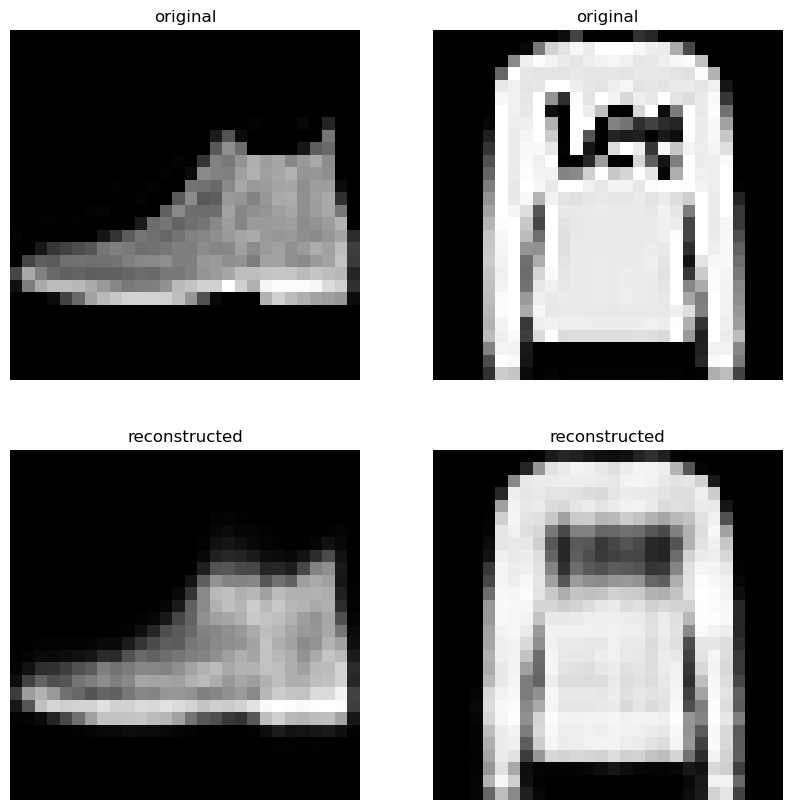

In [ ]:
#set your model to evaluation mode
model.eval()

#Get a batch of images from the test set and pass them through your trained autoencoder to get the reconstructions.
images, _=next(iter(test_loader))
with torch.no_grad():
    reconstructed=model(images)


#Create a plot showing two different original images from the test set and their corresponding reconstructions directly below them.
import matplotlib.pyplot as plt
fig,axes=plt.subplots(2,2,figsize=(10,10))

for i in range(2):
    #original images
    axes[0,i].imshow(images[i].squeeze(),cmap='gray')
    axes[0,i].axis('off')

#reconstructed images
    axes[1,i].imshow(reconstructed[i].squeeze(),cmap='gray')
    axes[1,i].axis('off')

# A single figure containing 4 images (2 original test images, 2 reconstructed images), clearly labeled
axes[0,0].set_title("original",fontsize=12, color='black')
axes[1,0].set_title("reconstructed",fontsize=12,color='black')
axes[0,1].set_title("original",fontsize=12, color='black')
axes[1,0].set_title("reconstructed",fontsize=12,color='black')
axes[1,1].set_title("reconstructed",fontsize=12,color='black')

plt.show()

